<a href="https://colab.research.google.com/github/UghurKhalilov/Movie-Ratings-Analysis-Polars/blob/main/Movie_Ratings_Analysis_Polars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring and Analyzing Movie Ratings with Polars: Project



## Step 1: Load and Inspect the Data

Loaded three CSV files — movies.csv, ratings.csv, and tags.csv —
into Polars DataFrames and inspected their general structure using
glimpse() and head().

**movies.csv** contains 9,742 rows and 3 columns:
- `movieId` — unique integer ID for each movie
- `title` — movie title including release year in parentheses
- `genres` — pipe-separated list of genres (e.g., 'Comedy|Drama')

**ratings.csv** contains 100,836 rows and 4 columns:
- `userId` — unique integer ID for each user
- `movieId` — integer ID referencing the movies table
- `rating` — float rating score ranging from 0.5 to 5.0
- `timestamp` — Unix timestamp of when the rating was given

**tags.csv** contains 3,683 rows and 4 columns:
- `userId` — unique integer ID for each user
- `movieId` — integer ID referencing the movies table
- `tag` — user-generated string tag (e.g., 'funny', 'classic')
- `timestamp` — Unix timestamp of when the tag was added

All columns were loaded with correct data types — no manual type
conversion was required at this stage.

In [4]:
import polars as pl

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
movies = pl.read_csv('/content/movies.csv')
ratings = pl.read_csv('/content/ratings.csv')
tags = pl.read_csv('/content/tags.csv')

In [7]:
movies.head()

movieId,title,genres
i64,str,str
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…"
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy"""
3,"""Grumpier Old Men (1995)""","""Comedy|Romance"""
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance"""
5,"""Father of the Bride Part II (1…","""Comedy"""


In [8]:
ratings.head()

userId,movieId,rating,timestamp
i64,i64,f64,i64
1,1,4.0,964982703
1,3,4.0,964981247
1,6,4.0,964982224
1,47,5.0,964983815
1,50,5.0,964982931


In [9]:
tags.head()

userId,movieId,tag,timestamp
i64,i64,str,i64
2,60756,"""funny""",1445714994
2,60756,"""Highly quotable""",1445714996
2,60756,"""will ferrell""",1445714992
2,89774,"""Boxing story""",1445715207
2,89774,"""MMA""",1445715200


#### Step 2: Data Preprocessing

Before proceeding with analysis, all three tables were systematically
checked for missing values and duplicate records.

**Missing Values:**
- movies — 0 missing values across all columns
- ratings — 0 missing values across all columns
- tags — 0 missing values across all columns

No missing values were found in any of the tables, so no imputation
or removal was necessary.

**Duplicate Records:**
- movies — 0 fully duplicate rows detected
- ratings — 0 fully duplicate rows detected
- tags — 0 fully duplicate rows detected

No duplicate records were found across any of the tables. This suggests
the dataset was already cleaned prior to distribution, which is common
for publicly available benchmark datasets like MovieLens.

The dataset is clean and fully ready for exploratory analysis.

In [10]:
movies.null_count()

movieId,title,genres
u32,u32,u32
0,0,0


In [11]:
movies.is_duplicated()

""
bool
false
false
false
false
false
…
false
false
false


In [12]:
movies.is_duplicated().sum()

0

In [13]:
ratings.null_count()

userId,movieId,rating,timestamp
u32,u32,u32,u32
0,0,0,0


In [14]:
ratings.is_duplicated().sum()

0

In [15]:
tags.null_count()

userId,movieId,tag,timestamp
u32,u32,u32,u32
0,0,0,0


In [16]:
tags.is_duplicated().sum()

0

## Validating Rating Values

Verifying that all values in the rating column fall within the
expected range of 0.5 to 5.0 by printing the minimum and maximum values.

In [17]:
ratings.select(
    pl.col('rating').min().alias('min_rating'),
    pl.col('rating').max().alias('max_rating')
)

min_rating,max_rating
f64,f64
0.5,5.0


## Distribution of Rating Scores

Computing the count of ratings for each score from 0.5 to 5.0
to understand how users distribute their ratings.

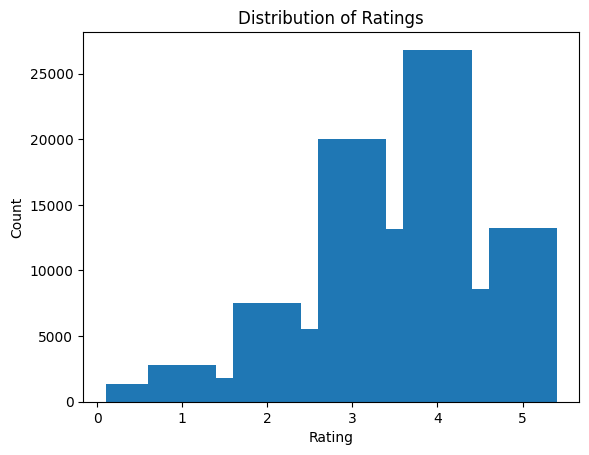

In [68]:
import matplotlib.pyplot as plt

rating_counts = ratings.group_by('rating').agg(pl.len().alias('count')).sort('rating')

plt.bar(rating_counts['rating'], rating_counts['count'])
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.show()

## Average Rating per Genre

Computing the average rating for each genre by exploding the pipe-separated
genres column and grouping by genre.

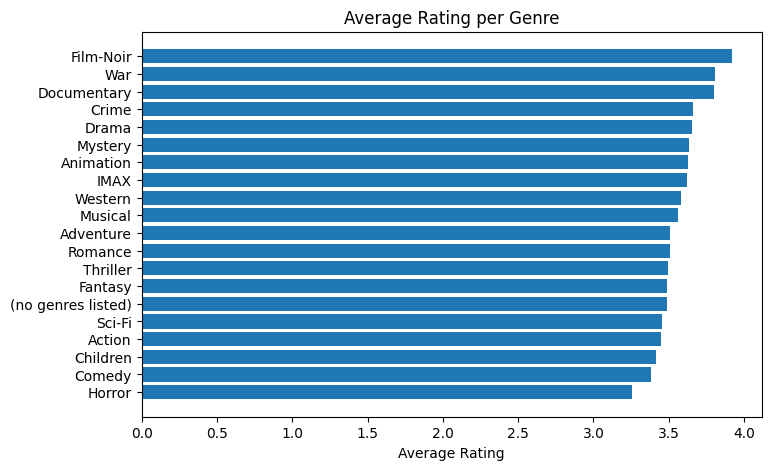

In [92]:
genre_avg = movies.with_columns(
    pl.col('genres').str.split('|')
).explode('genres').join(
    ratings, on='movieId'
).group_by('genres').agg(
    pl.col('rating').mean().alias('avg_rating')
).sort('avg_rating', descending=True)

plt.figure(figsize=(8, 5))
plt.barh(genre_avg['genres'], genre_avg['avg_rating'])
plt.xlabel('Average Rating')
plt.title('Average Rating per Genre')
plt.gca().invert_yaxis()
plt.show()

## Rating Activity per User

Computing the minimum, maximum, and mean number of ratings per user
to understand the range of user engagement on the platform.

In [20]:
ratings.group_by(pl.col('userId')).agg(
    pl.len().alias('count')
).select(
    pl.col('count').min().alias('min'),
    pl.col('count').max().alias('max'),
    pl.col('count').mean().alias('mean')
)

min,max,mean
u32,u32,f64
20,2698,165.304918


## Top 5 Users with the Most Ratings

Identifying the 5 most active users on the platform based on
the number of ratings they have submitted.

In [21]:
ratings.group_by('userId').agg(pl.len().alias('count')
).sort('count',descending=True).head(5)


userId,count
i64,u32
414,2698
599,2478
474,2108
448,1864
274,1346


## Average Rating: Top 10 vs Bottom 10 Most Rated Movies

Comparing the average rating of the 10 most frequently rated movies
against the 10 least rated movies (with at least 5 ratings) to see
if popularity correlates with quality.

In [30]:
movie_rating=ratings.group_by('movieId').agg(pl.len().alias('count'),
                                pl.col('rating').mean().alias('avg_rating')
).filter(pl.col('count')>=5)

top10=movie_rating.sort('count',descending=True).head(10)

buttom10=movie_rating.sort('count',descending=False).head(10)

print(f'Top 10 filmin ortalamasi: {top10['avg_rating'].mean()}')
print(f'Buttom 10 filmin ortalamasi: {buttom10['avg_rating'].mean()}')

Top 10 filmin ortalamasi: 4.135266399996421
Buttom 10 filmin ortalamasi: 3.28


## Distribution of Number of Ratings per Movie

Analyzing how ratings are distributed across movies — how many movies
have 1 rating, 2 ratings, and so on up to the maximum.

In [41]:
movie_rating['count'].value_counts(name='num_movies').sort('count')

count,num_movies
u32,u32
5,382
6,319
7,278
8,230
9,172
…,…
278,1
279,1
307,1


## Top 20 Most Frequently Rated Movies

Identifying the 20 movies that received the most ratings, displaying
their ID, title, and rating count.

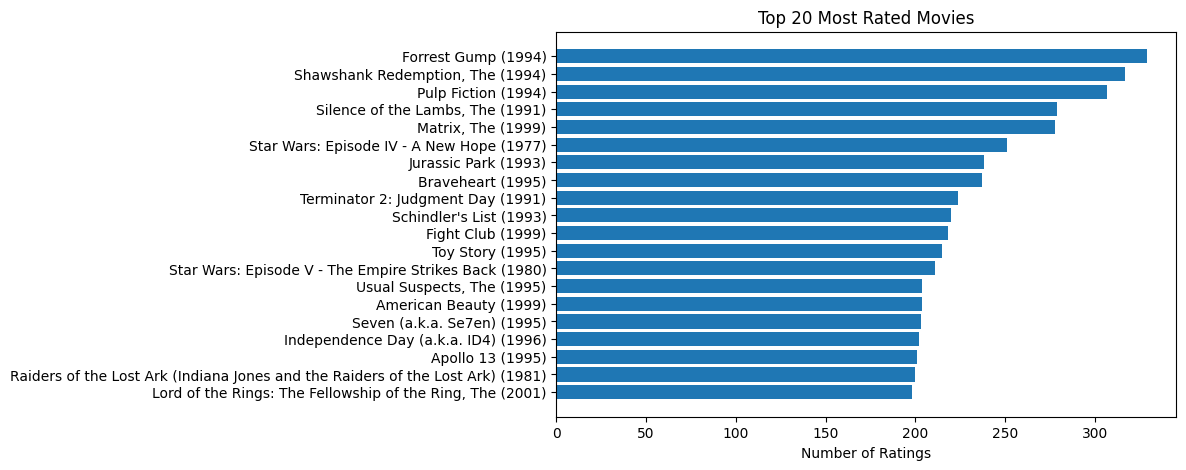

In [93]:
top20 = movie_rating.join(movies, on='movieId').select(
    pl.col('movieId'), pl.col('title'), pl.col('count')
).sort('count', descending=True).head(20)

plt.figure(figsize=(8, 5))
plt.barh(top20['title'], top20['count'])
plt.xlabel('Number of Ratings')
plt.title('Top 20 Most Rated Movies')
plt.gca().invert_yaxis()
plt.show()

## Total Unique Genres and Top 10 Most Common Genres

Computing the total number of unique genres in the dataset and identifying
the top 10 most frequently occurring genres with their counts.

In [56]:
total_genres=movies.with_columns(
    pl.col('genres').str.split('|')
).explode('genres')

unique_genres=total_genres['genres'].n_unique()

top_10_genres=total_genres.group_by('genres').agg(pl.len().alias('count')
).sort('count',descending=True).head(10)
print(f'total number of unique genres: {unique_genres}')
print(top_10_genres)

total number of unique genres: 20
shape: (10, 2)
┌───────────┬───────┐
│ genres    ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ Drama     ┆ 4361  │
│ Comedy    ┆ 3756  │
│ Thriller  ┆ 1894  │
│ Action    ┆ 1828  │
│ Romance   ┆ 1596  │
│ Adventure ┆ 1263  │
│ Crime     ┆ 1199  │
│ Sci-Fi    ┆ 980   │
│ Horror    ┆ 978   │
│ Fantasy   ┆ 779   │
└───────────┴───────┘


## Number of Movies and Average Rating per Genre

For each genre, computing the total number of movies and average rating
to identify which genres are most prevalent and highest rated.

In [64]:
genre_count=total_genres.join(ratings,on='movieId').group_by('genres').agg(pl.len().alias('count'),pl.col('rating').mean().alias('avg_rating_genre')
).sort('avg_rating_genre',descending=True)
genre_count

genres,count,avg_rating_genre
str,u32,f64
"""Film-Noir""",870,3.920115
"""War""",4859,3.808294
"""Documentary""",1219,3.797785
"""Crime""",16681,3.658294
"""Drama""",41928,3.656184
…,…,…
"""Sci-Fi""",17243,3.455721
"""Action""",30635,3.447984
"""Children""",9208,3.412956


## Average Number of Tags per Movie

Computing the average number of tags per movie, along with the minimum
and maximum, to understand how actively users engage with tagging behavior.

In [67]:
tags.group_by('movieId').agg(pl.len().alias('count')
).select(pl.col('count').mean().alias('avg_tags'),
         pl.col('count').min().alias('min'),
         pl.col('count').max().alias('max'))

avg_tags,min,max
f64,u32,u32
2.342875,1,181


## Top 20 Most Frequently Used Tags

Identifying the 20 tags that users apply most frequently across all movies,
revealing the most common themes and descriptors used by the community.

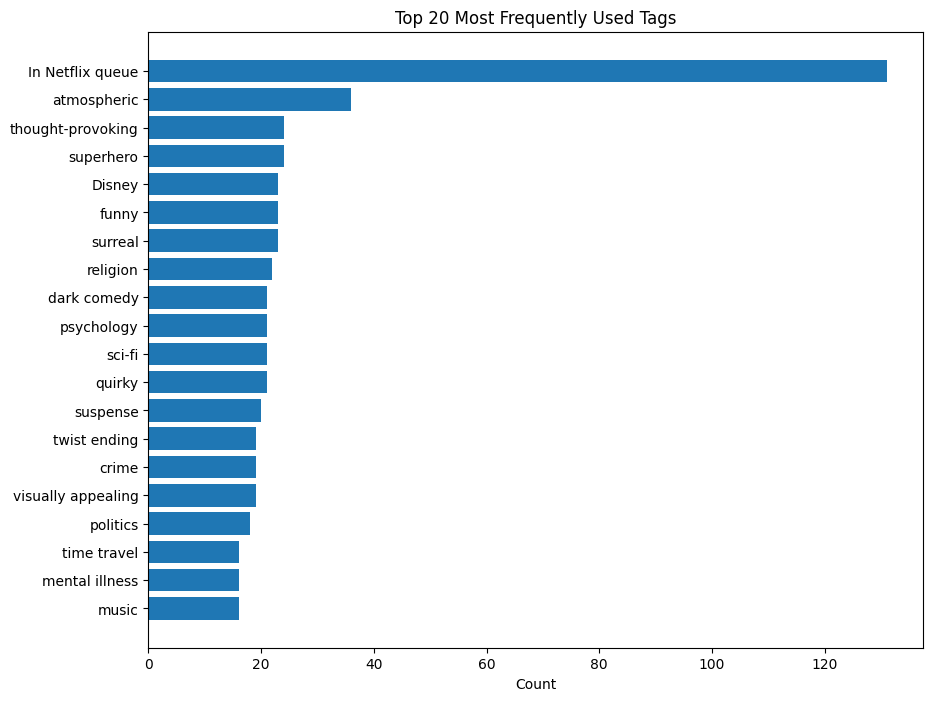

In [75]:
top20_tags = tags.group_by('tag').agg(pl.len().alias('tag_count')).sort('tag_count', descending=True).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20_tags['tag'], top20_tags['tag_count'])
plt.xlabel('Count')
plt.title('Top 20 Most Frequently Used Tags')
plt.gca().invert_yaxis()
plt.show()

## High Rating Proportion per Movie

For each movie with at least 5 ratings, computing the proportion of
ratings that are 4 or higher. This identifies movies that consistently
receive positive feedback from viewers.

In [80]:
(ratings.group_by('movieId').agg(
    pl.len().alias('count'),
    (pl.col('rating') >= 4).mean().alias('high_rating_proportion')
)
.filter(pl.col('count') >= 5)
.join(movies, on='movieId')
.select(
    pl.col('movieId'),
    pl.col('title'),
    pl.col('high_rating_proportion'))
)

movieId,title,high_rating_proportion
i64,str,f64
1,"""Toy Story (1995)""",0.683721
2,"""Jumanji (1995)""",0.454545
3,"""Grumpier Old Men (1995)""",0.346154
4,"""Waiting to Exhale (1995)""",0.0
5,"""Father of the Bride Part II (1…",0.244898
…,…,…
180031,"""The Shape of Water (2017)""",0.5
180985,"""The Greatest Showman (2017)""",0.2
183897,"""Isle of Dogs (2018)""",0.4


## Re-rating Proportion per User

Computing the proportion of ratings that are re-ratings (multiple ratings
to the same movie) for each user, and identifying the top 10 users
with the highest re-rating proportion.

In [82]:
ratings.group_by(['userId','movieId']).agg(pl.len().alias('count')).filter(pl.col('count')>1)

userId,movieId,count
i64,i64,u32


## Top 20 Movies by Average Rating

Identifying the top 20 highest-rated movies with at least 10 ratings
to ensure statistical reliability. Displaying movie ID, title,
and average rating.

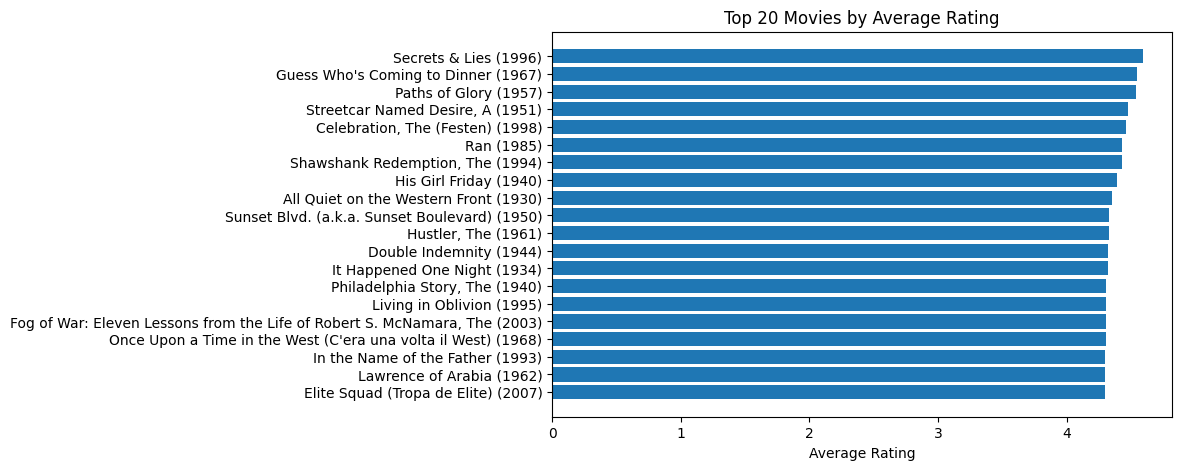

In [94]:
top20_movies = (movie_rating
.filter(pl.col('count') >= 10)
.join(movies, on='movieId')
.select('movieId', 'title', 'avg_rating')
.sort('avg_rating', descending=True)
.head(20))

plt.figure(figsize=(8, 5))
plt.barh(top20_movies['title'], top20_movies['avg_rating'])
plt.xlabel('Average Rating')
plt.title('Top 20 Movies by Average Rating')
plt.gca().invert_yaxis()
plt.show()

## Correlation Between Number of Ratings and Average Rating

Computing the correlation between the number of ratings a movie receives
and its average rating to understand whether popular movies tend to be
rated higher or lower.

In [91]:
movie_rating.select(
    pl.corr('count', 'avg_rating'))

count
f64
0.256506
